In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/synthetic_expenses.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,user_id,day,day_of_week,amount_spent_today,category,mood_while_spending,days_left_in_month,percent_budget_used_so_far,spending_trend,monthly_budget,overspending_risk
0,1,1,1,288.80,Other,Impulsive,29,1.16,0.00,25000,Medium
1,1,2,2,3282.21,Other,Stressed,28,14.28,0.00,25000,Medium
2,1,3,3,538.22,Other,Impulsive,27,16.44,0.00,25000,Medium
3,1,4,4,566.01,Other,Stressed,26,18.70,1173.35,25000,Medium
4,1,5,5,437.61,Shopping,Neutral,25,20.45,-1271.56,25000,Medium


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     15000 non-null  int64  
 1   day                         15000 non-null  int64  
 2   day_of_week                 15000 non-null  int64  
 3   amount_spent_today          15000 non-null  float64
 4   category                    15000 non-null  str    
 5   mood_while_spending         15000 non-null  str    
 6   days_left_in_month          15000 non-null  int64  
 7   percent_budget_used_so_far  15000 non-null  float64
 8   spending_trend              15000 non-null  float64
 9   monthly_budget              15000 non-null  int64  
 10  overspending_risk           15000 non-null  str    
dtypes: float64(3), int64(5), str(3)
memory usage: 1.3 MB


user_id                       0
day                           0
day_of_week                   0
amount_spent_today            0
category                      0
mood_while_spending           0
days_left_in_month            0
percent_budget_used_so_far    0
spending_trend                0
monthly_budget                0
overspending_risk             0
dtype: int64

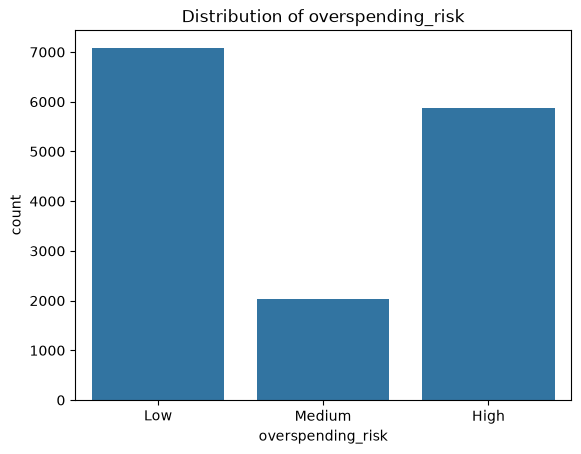

In [3]:
sns.countplot(data=df, x="overspending_risk", order=["Low", "Medium", "High"])
plt.title("Distribution of overspending_risk")
plt.show()

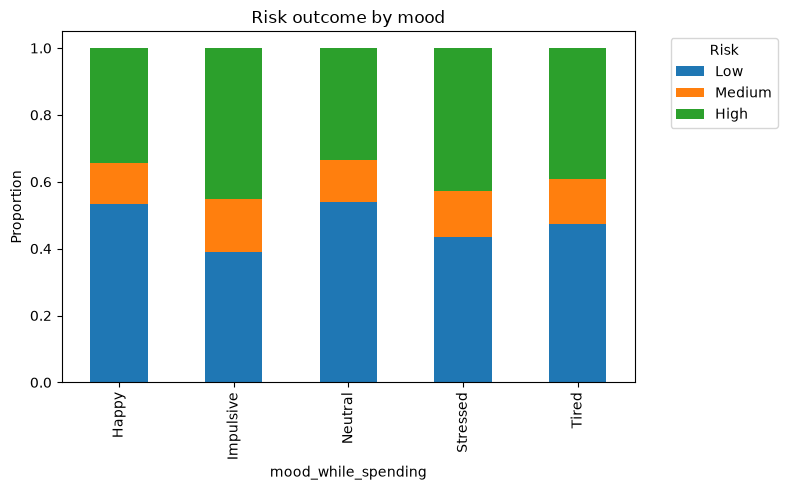

In [4]:
mood_risk = pd.crosstab(df["mood_while_spending"], df["overspending_risk"], normalize="index")
mood_risk = mood_risk[["Low", "Medium", "High"]]  # consistent column order
mood_risk.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Risk outcome by mood")
plt.ylabel("Proportion")
plt.legend(title="Risk", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

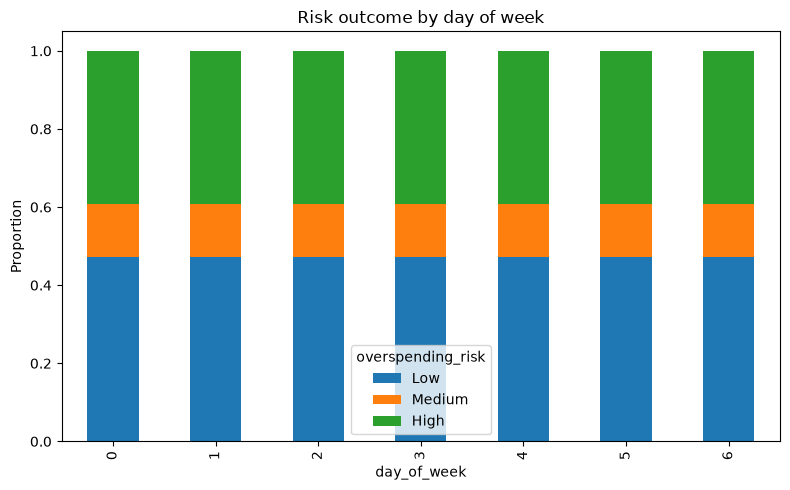

In [5]:
dow_risk = pd.crosstab(df["day_of_week"], df["overspending_risk"], normalize="index")
dow_risk = dow_risk[["Low", "Medium", "High"]]
dow_risk.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Risk outcome by day of week")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

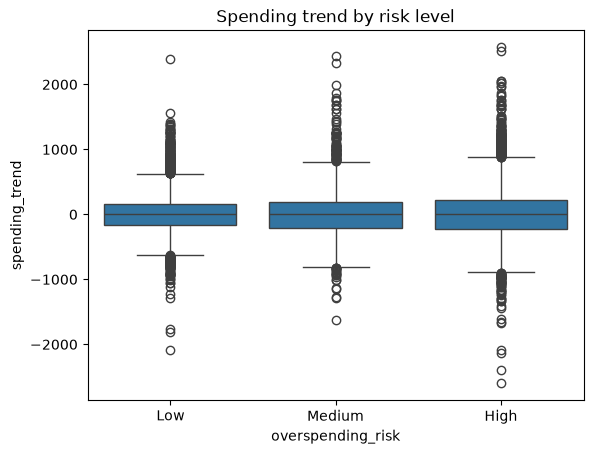

In [6]:
sns.boxplot(data=df, x="overspending_risk", y="spending_trend", order=["Low", "Medium", "High"])
plt.title("Spending trend by risk level")
plt.show()

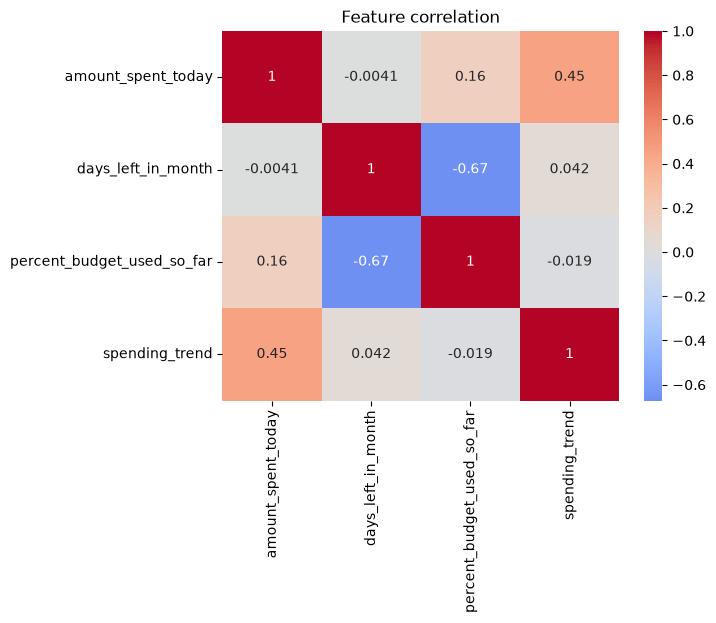

In [7]:
numeric_cols = ["amount_spent_today", "days_left_in_month", "percent_budget_used_so_far", "spending_trend"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature correlation")
plt.show()